<a href="https://colab.research.google.com/github/r021n/simple-machine-learing/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 — Setup and Understand the Problem

##  Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

## Load dataset heart_disease.csv

In [2]:
from google.colab import files
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

Saving heart_disease_uci.csv to heart_disease_uci.csv


##  Cek struktur data awal

In [3]:
print("Shape dataset:", df.shape)
display(df.head())
print("\n--- Info tipe data ---")
df.info()
print("\n--- Statistik deskriptif ---")
display(df.describe(include='all'))

Shape dataset: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



--- Info tipe data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

--- Statistik deskriptif ---


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


## Mengubah target jadi binary dan dokumentasi kolom

In [4]:
df['target'] = (df['num'] > 0).astype(int)

print("Distribusi target binary:")
print(df["target"].value_counts())

Distribusi target binary:
target
1    509
0    411
Name: count, dtype: int64


# Phase 2 — Data Exploration and Cleaning

## Cek missing values dan duplikat

In [5]:
print("Missing values per kolom")
print(df.isnull().sum())

print("\nJumlah baris duplikat:", df.duplicated().sum())

Missing values per kolom
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
target        0
dtype: int64

Jumlah baris duplikat: 0


## Menangani outlier yang tidak masuk akal

In [6]:
impossible_idx = df[(df['trestbps'] == 0) | (df['chol'] == 0) | (df['thal'] == 0)].index

print(f"Baris dengan nilai yang mustahil ditemukan: {len(impossible_idx)}")
df_clean = df.drop(index=impossible_idx).copy().reset_index(drop=True)

print("Shape sebelum:", df.shape, "->", "Shape sesudah:", df_clean.shape)

Baris dengan nilai yang mustahil ditemukan: 172
Shape sebelum: (920, 17) -> Shape sesudah: (748, 17)


## Melihat distribusi fitur terhadap target

/tmp/ipykernel_6392/971922201.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='target', y=col, ax=axes[i,1], palette='Set1')
/tmp/ipykernel_6392/971922201.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='target', y=col, ax=axes[i,1], palette='Set1')
/tmp/ipykernel_6392/971922201.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='target', y=col, ax=axes[i,1], palette='Set1')
/tmp/ipykernel_6392/971922201.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

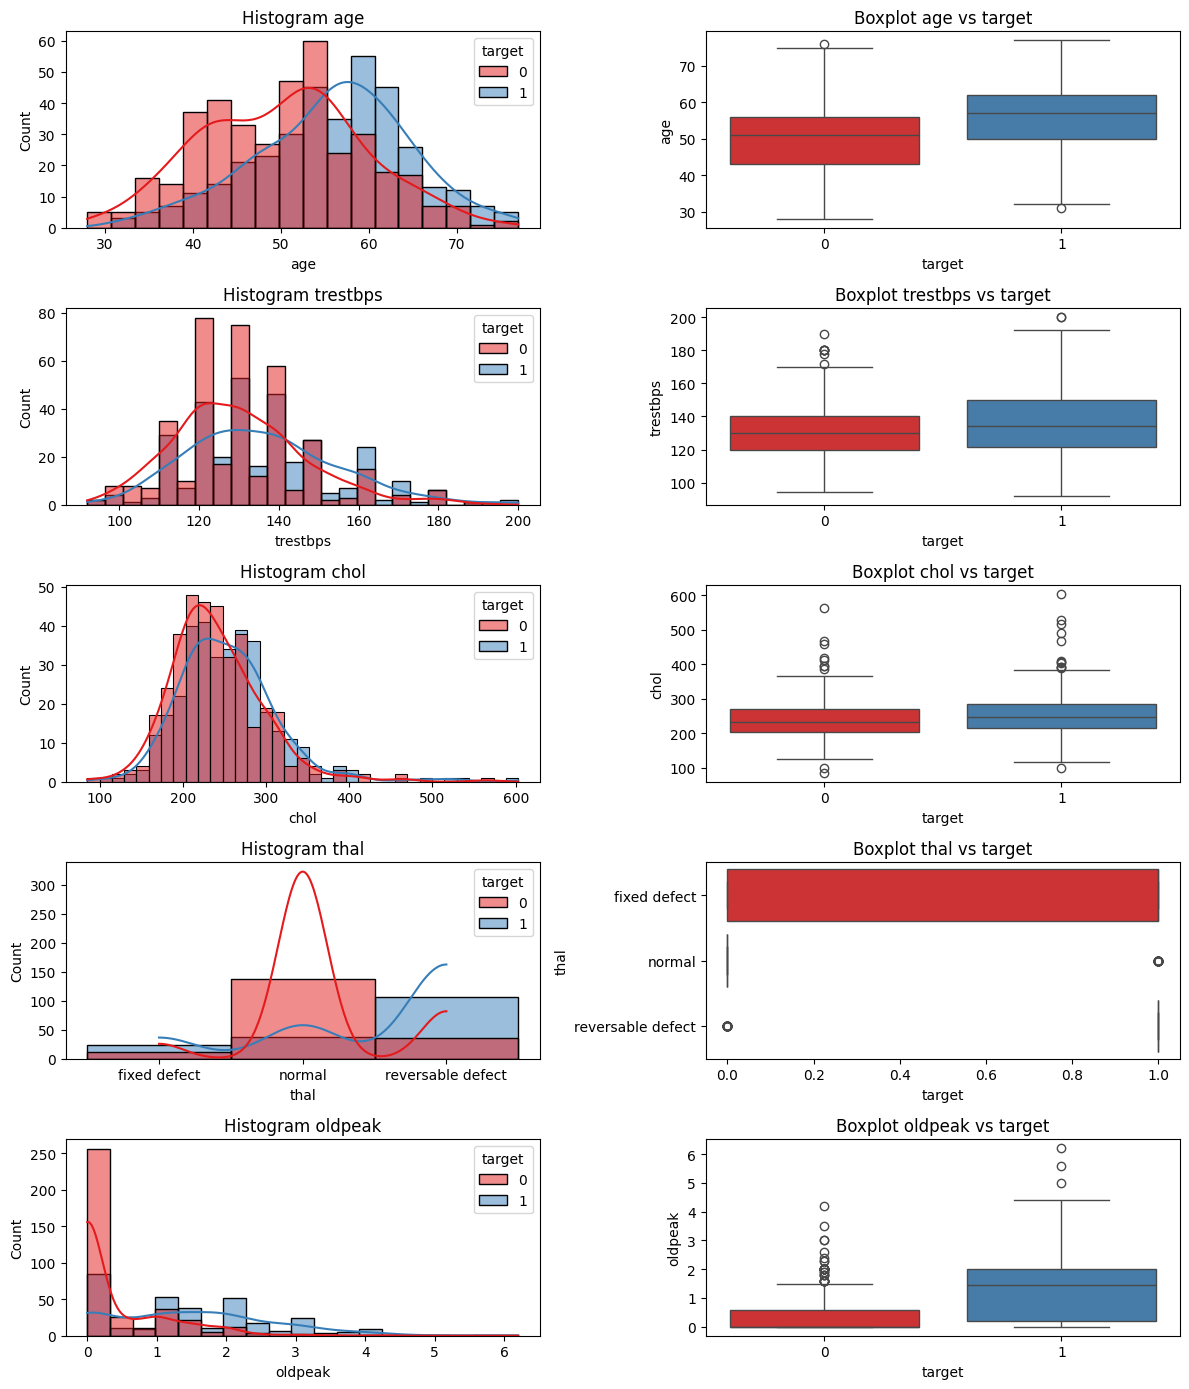

In [7]:
num_cols = ["age", "trestbps", "chol", "thal", "oldpeak"]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 14))
for i, col in enumerate(num_cols):
  sns.histplot(data=df_clean, x=col, hue='target', kde=True, ax=axes[i, 0], palette='Set1')
  axes[i,0].set_title(f'Histogram {col}')
  sns.boxplot(data=df_clean, x='target', y=col, ax=axes[i,1], palette='Set1')
  axes[i,1].set_title(f'Boxplot {col} vs target')
plt.tight_layout()
plt.show()

## Mengkonversi exang dari object ke boolean

In [9]:
df_clean['exang'] = df_clean['exang'].astype(str).str.strip().str.upper()
df_clean['exang'] = df_clean['exang'].map({"TRUE": 1, "FALSE": 0, 'YES':1, 'NO':0, '1':1, '0':0})
df_clean['exang'] = df_clean['exang'].fillna(0).astype(int)

## Membuat heatmap korelasi

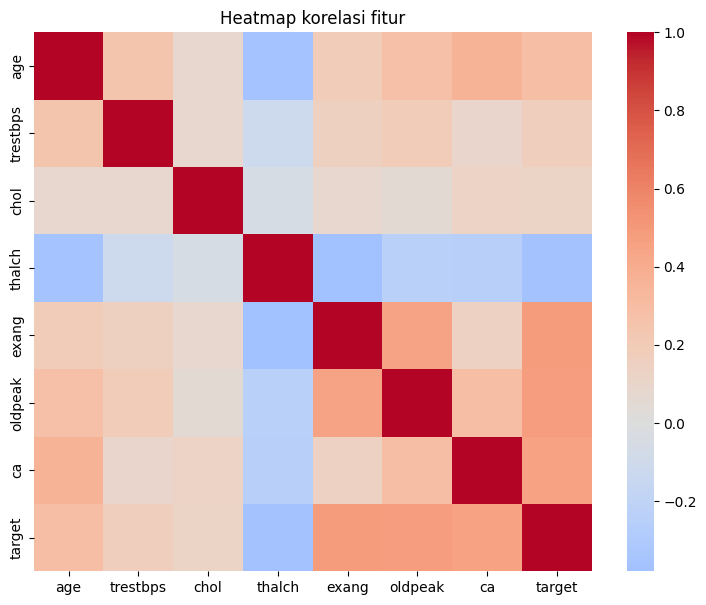

Korelasi dengan target (urut dari yang tertinggi)
target      1.000000
exang       0.482860
oldpeak     0.478564
ca          0.455084
age         0.299401
trestbps    0.169093
chol        0.118327
thalch     -0.364574
Name: target, dtype: float64


In [10]:
numeric_df = df_clean.select_dtypes(include=[np.number]).drop(columns=["id","num"], errors="ignore")

corr = numeric_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Heatmap korelasi fitur")
plt.show()

print("Korelasi dengan target (urut dari yang tertinggi)")
print(corr["target"].sort_values(ascending=False))

# Phase 3 — Data Preprocessing and Sharing

## Cek dan encode semua fitur kategorikal

In [12]:
print(df_clean.dtypes)

df_model = df_clean.copy()

df_model['sex'] = df_model['sex'].map({'Male':1, 'Female':0, 'M':1, 'F':0})
df_model['fbs'] = df_model['fbs'].astype(str).str.upper().map({'TRUE':1,'FALSE':0,'1':1,'0':0}).fillna(0).astype(int)
df_model['ca'] = pd.to_numeric(df_model['ca'], errors='coerce').fillna(0)

df_model['exang'] = df_model['exang'].astype(int)

df_model = pd.get_dummies(df_model, columns=['cp','restecg','slope','thal','dataset'], drop_first=True)

id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang         int64
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
target        int64
dtype: object


## Memisahkan X dan y

In [13]:
y = df_model['target']
X = df_model.drop(columns=["id", "num", "target"], errors="ignore")

print("Fitur:", X.shape[1], "Kolom")
print("Distribusi kelas:\n", y.value_counts(normalize=True))

Fitur: 20 Kolom
Distribusi kelas:
 target
0    0.522727
1    0.477273
Name: proportion, dtype: float64


## Train test split and standardization

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

num_to_scale = ['age','trestbps','chol','thalch','oldpeak','ca']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_to_scale] = scaler.fit_transform(X_train[num_to_scale])
X_test_scaled[num_to_scale] = scaler.transform(X_test[num_to_scale])

print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)

Train: (598, 20) Test: (150, 20)
